# Load cleaned data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# load data from global_weather_cleaded.csv

df = pd.read_csv(
    './global_weather_cleaned.csv',
    parse_dates=[
        'last_updated',
        'sunrise',
        'sunset',
        'moonrise',
        'moonset'
        ]
)
df.shape

(144034, 41)

# Unique Analyses

## Weather Relationships

### Temperature vs Humidity

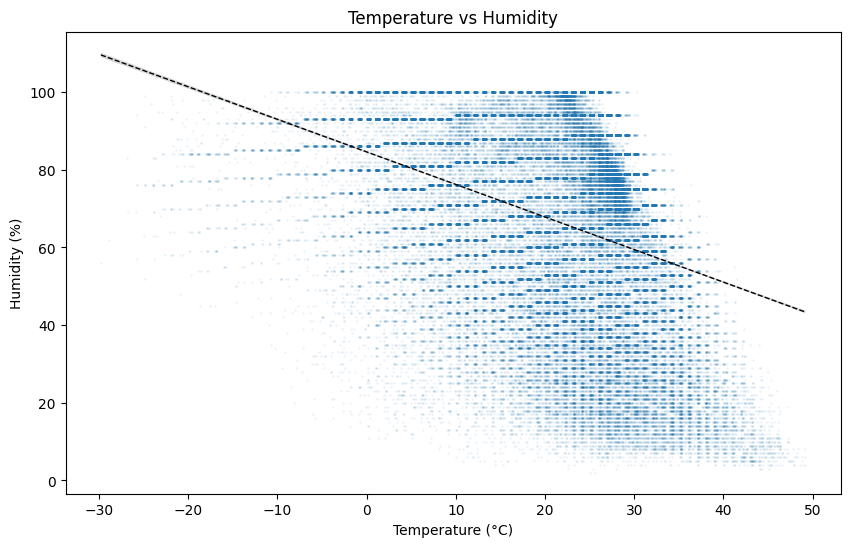

In [4]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='temperature_celsius',
    y='humidity',
    scatter_kws={'s':1, 'alpha':0.05},
    line_kws={'linewidth':1, 'color':'black', 'linestyle':'--'}
)

plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')

plt.show()

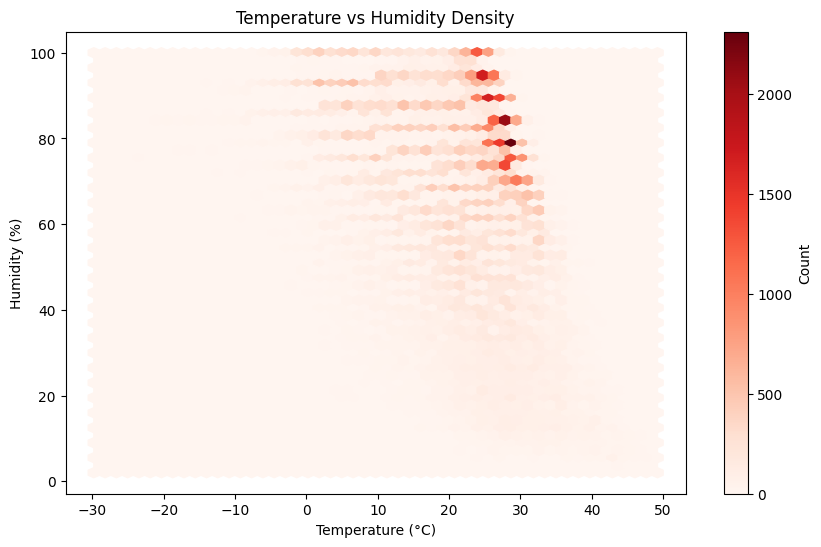

In [5]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df['temperature_celsius'],
    df['humidity'],
    gridsize=50,
    cmap='Reds'
)

plt.colorbar(label='Count')

plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs Humidity Density')

plt.show()

In [6]:
df[['temperature_celsius', 'humidity']].corr()

,temperature_celsius,humidity
temperature_celsius,1.000000,-0.338948
humidity,-0.338948,1.000000


- Temperature and humidity exhibit a low inverse relationship.
- As temperatures increase, humidity generally decreases. 
- The highest concentration of observations occurs between 25–30°C and 70–90% humidity, indicating many locations experience warm and humid conditions.
- The triangular distribution suggests that while moderate temperatures can occur across a wide range of humidity levels, very high temperatures are less frequently associated with extremely high humidity.

### Wind Speed vs Pressure

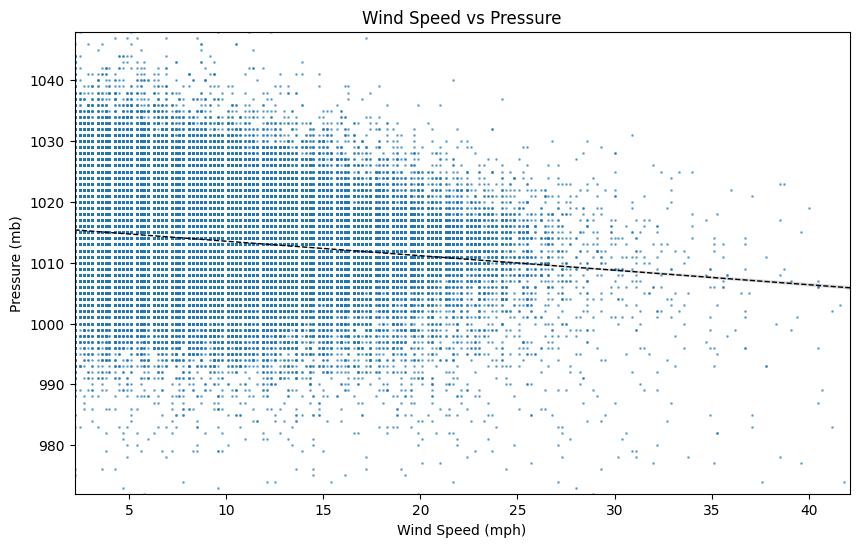

In [7]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='wind_mph',
    y='pressure_mb',
    scatter_kws={'s':1, 'alpha':0.5},
    line_kws={'linewidth':1, 'color':'black', 'linestyle':'--'}
)

plt.xlim(
    df['wind_mph'].quantile(0.0001),
    df['wind_mph'].quantile(0.9999)
)
plt.ylim(
    df['pressure_mb'].quantile(0.0001),
    df['pressure_mb'].quantile(0.9999)
)
plt.title('Wind Speed vs Pressure')
plt.xlabel('Wind Speed (mph)')
plt.ylabel('Pressure (mb)')

plt.show()

In [8]:
df[['wind_mph', 'pressure_mb']].corr()

,wind_mph,pressure_mb
wind_mph,1.000000,-0.178969
pressure_mb,-0.178969,1.000000


- Wind speed and atmospheric pressure exhibit only a weak negative relationship.
- Most observations occur between approximately 2–25 mph and 995–1030 mb, with considerable variability in pressure across all wind speeds.

### Cloud cover, Precipitation and Humidity

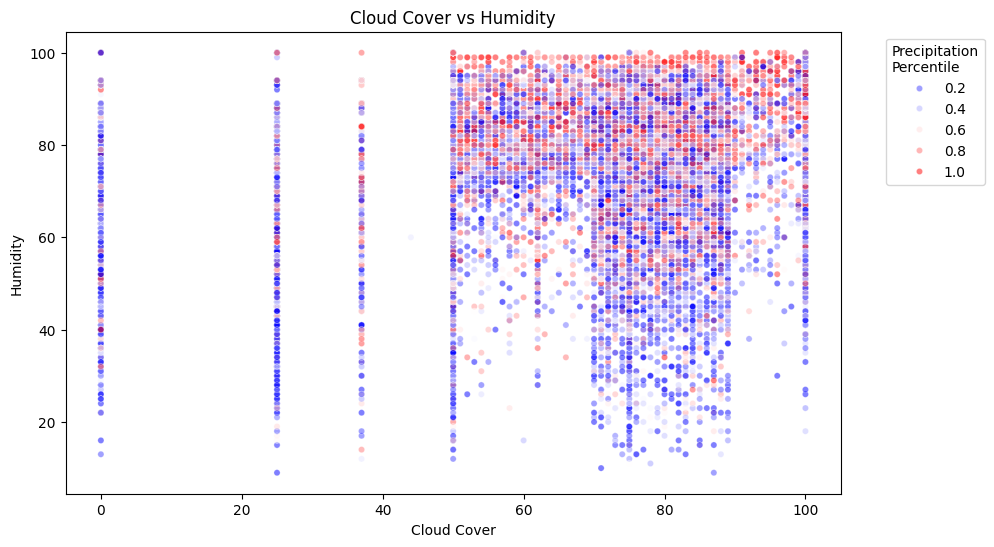

In [9]:
import numpy as np

plt.figure(figsize=(10,6))

# Handle zero inflated precipitation
# Take only pricip > 0
df_filtered = df[df['precip_mm'] > 0]

# Precip_mm is very skewed.
# Even taking log1p, it is still skewed.
# Scatterplot hue does not show much difference it makes.

# df_filtered['precip_log'] = np.log1p(df_filtered['precip_mm'])

# sns.scatterplot(
#     data=df_filtered,
#     x='cloud',
#     y='humidity',
#     hue='precip_log',
#     palette='bwr',
#     s=20,
#     alpha=0.5
# )

# Coloring my percentile rank of precip_mm instead of log1p
df_filtered['precip_pct'] = (
    df_filtered['precip_mm']
    .rank(pct=True)
)

sns.scatterplot(
    data=df_filtered,
    x='cloud',
    y='humidity',
    hue='precip_pct',
    palette='bwr',
    s=20,
    alpha=0.5
)

plt.legend(
    title='Precipitation\nPercentile',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title('Cloud Cover vs Humidity')
plt.xlabel('Cloud Cover')
plt.ylabel('Humidity')

plt.show()

Higher precipitation percentiles are associated with higher humidity levels, while cloud cover shows a weaker relationship with precipitation intensity. This suggests humidity is a stronger indicator of rainfall intensity than cloud cover in this dataset.

- Cloud cover alone is not a strong predictor of precipitation intensity.
    - At cloud cover between roughly 50–100%, all precipitation percentiles are present.
    - Both light and heavy precipitation occur under similar cloud cover conditions.

- Humidity generally increases with precipitation percentile.
    - The red/orange points (higher precipitation percentiles) are concentrated toward higher humidity values.
    - Low humidity (<40%) is dominated by blue points (lower precipitation percentiles).

- High precipitation is rare when humidity is low.
    - The upper precipitation percentiles (red points) are mostly observed above about 70% humidity.

- Humidity appears more informative than cloud cover for explaining precipitation intensity.
    - Moving vertically (humidity) produces a clearer color gradient than moving horizontally (cloud cover).

### Visibility vs Air Pollution

<Axes: xlabel='pollution_score', ylabel='visibility_km'>

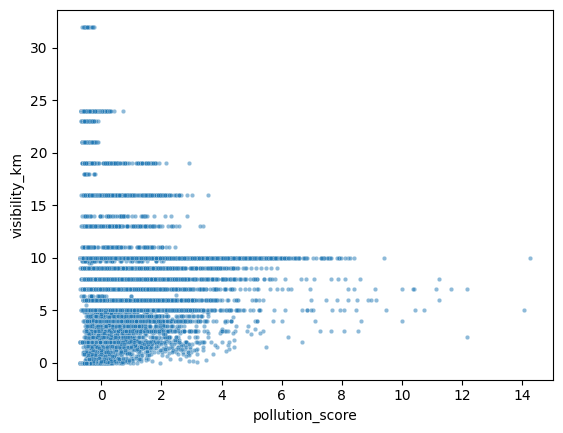

In [10]:
pollution_cols = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_gb-defra-index'
]

from sklearn.preprocessing import StandardScaler

# Standardize each pollutant (mean=0, std=1) so they are on the same scale,
# then compute the average standardized pollution level for each observation
# to create a single overall air pollution score.
df['pollution_score'] = (
    StandardScaler()
    .fit_transform(df[pollution_cols])
    .mean(axis=1)
)

sns.scatterplot(
    data=df,
    x='pollution_score',
    y='visibility_km',
    alpha=0.5,
    s=10
)

Visibility exhibits a weak-to-moderate negative relationship with the composite pollution score. While visibility varies substantially at low pollution levels, high visibility observations occur almost exclusively under low-pollution conditions. As pollution increases, the maximum observed visibility decreases, suggesting that elevated air pollution may constrain visibility even though additional meteorological factors also influence viewing distance.

## Geographic Analysis

### Temperature vs Latitude

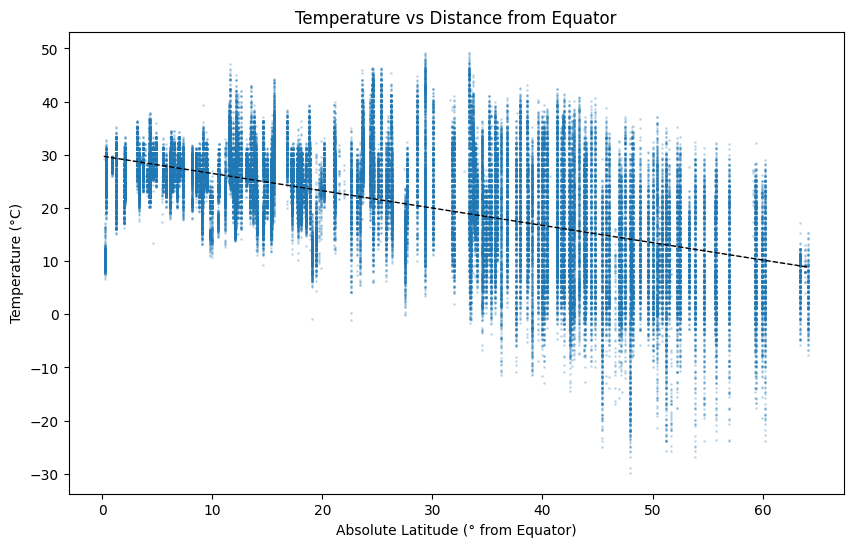

In [11]:
# Taking absolute value of latitude to see distance from equator instead of north/south hemisphere

df['abs_latitude'] = df['latitude'].abs()

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='abs_latitude',
    y='temperature_celsius',
    scatter_kws={'s':1, 'alpha':0.2},
    line_kws={'linewidth':1, 'color':'black', 'linestyle':'--'}
)

plt.title('Temperature vs Distance from Equator')
plt.xlabel('Absolute Latitude (° from Equator)')
plt.ylabel('Temperature (°C)')

plt.show()

Temperatures generally decrease with increasing distance from the equator, confirming latitude as a major determinant of climate. Nevertheless, the substantial spread of observations at each latitude indicates that local geographic and seasonal factors also play an important role in determining temperature.

### UV Index vs Latitude

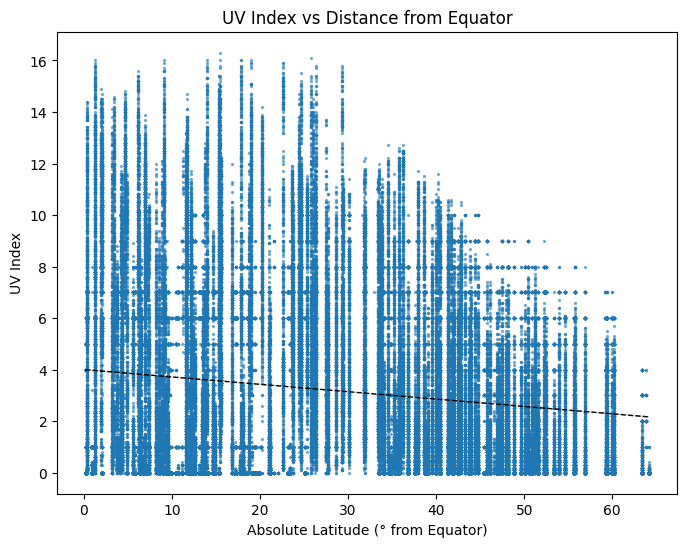

In [12]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='abs_latitude',
    y='uv_index',
    scatter_kws={'s':2, 'alpha':0.5},
    line_kws={'linewidth':1, 'color':'black', 'linestyle':'--'}
)

plt.title('UV Index vs Distance from Equator')
plt.xlabel('Absolute Latitude (° from Equator)')
plt.ylabel('UV Index')

plt.show()

UV index generally decreases as distance from the equator increases. Locations closer to the equator experience higher and more variable UV levels, while higher latitudes tend to have lower UV exposure. The wide spread of values suggests that latitude is an important but not exclusive determinant of UV intensity.

### Hemisphere comparison

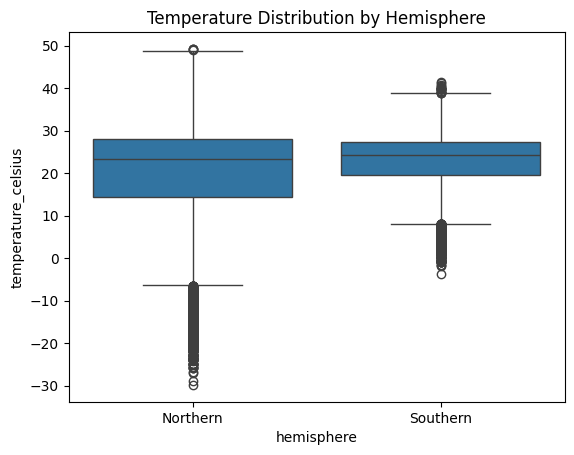

In [13]:
df['hemisphere'] = np.where(
    df['latitude'] >= 0,
    'Northern',
    'Southern'
)

sns.boxplot(
    data=df,
    x='hemisphere',
    y='temperature_celsius'
)

plt.title('Temperature Distribution by Hemisphere')
plt.show()

The Southern Hemisphere exhibits a slightly higher median temperature, while the Northern Hemisphere shows substantially greater temperature variability. The Northern Hemisphere contains both the coldest and warmest observations, likely due to its larger landmass and more continental climates. In contrast, the ocean-dominated Southern Hemisphere experiences a more moderate temperature range.

### Climate zones

In [14]:
df['latitude'].abs().max()

np.float64(64.15)

In [15]:
def climate_zone(latitude):
    latitude = abs(latitude)

    if latitude < 23.5:
        return 'Tropical'
    elif latitude < 40:
        return 'Subtropical'
    elif latitude < 60:
        return 'Temperate'
    else:
        return 'Subpolar'
    
df['climate_zone'] = df['latitude'].apply(climate_zone)

df['climate_zone'].value_counts()

climate_zone
Tropical       71608
Temperate      37275
Subtropical    33673
Subpolar        1478
Name: count, dtype: int64

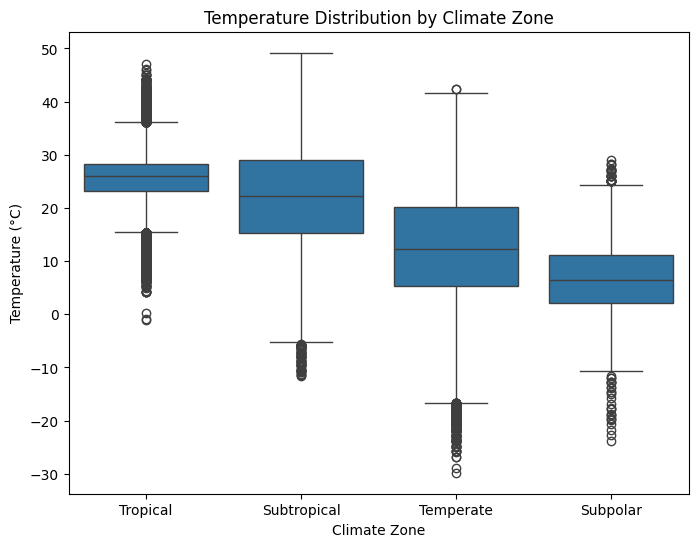

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='climate_zone',
    y='temperature_celsius',
    order=['Tropical', 'Subtropical', 'Temperate', 'Subpolar']
)

plt.title('Temperature Distribution by Climate Zone')
plt.xlabel('Climate Zone')
plt.ylabel('Temperature (°C)')

plt.show()

Temperature distributions vary substantially across climate zones. Median temperatures decrease progressively from Tropical to Subpolar regions, demonstrating the strong influence of latitude on climate. Tropical regions exhibit consistently warm temperatures with relatively low variability, whereas Temperate and Subpolar regions experience much broader temperature ranges due to stronger seasonal effects. The observed pattern aligns with expected global climate gradients, where locations farther from the equator receive less solar energy and therefore maintain lower average temperatures.

## Temporal Analysis


### Monthly average temperature

In [19]:
df['last_updated'].dtype

dtype('<M8[us]')

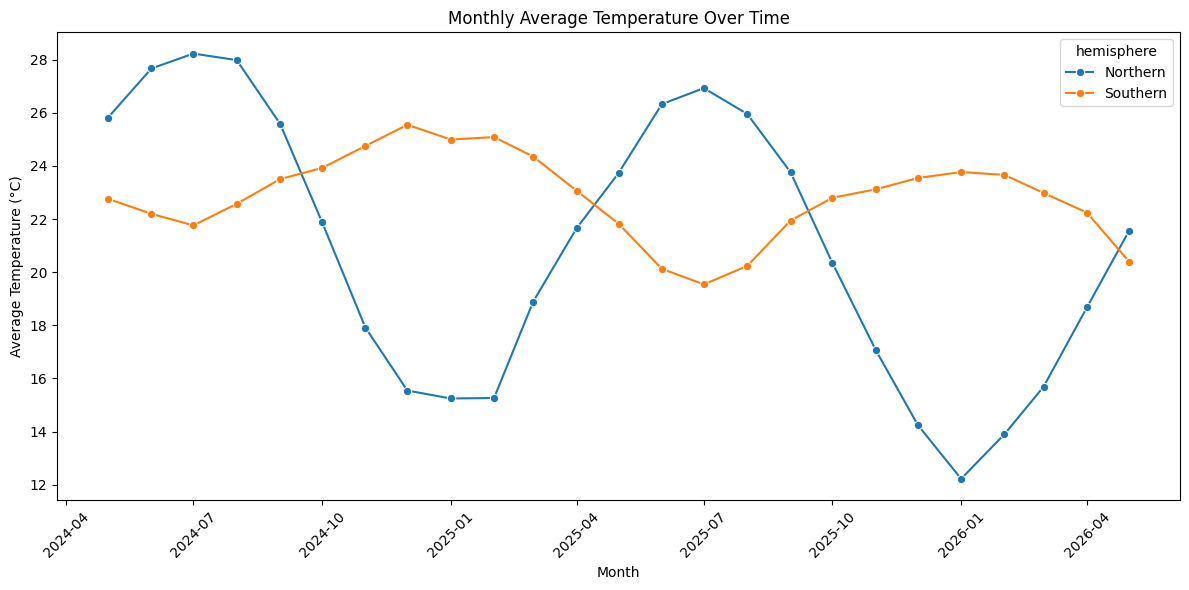

In [20]:
# Monthly average temperature over time for both hemispheres

df['hemisphere'] = np.where(
    df['latitude'] >= 0,
    'Northern',
    'Southern'
)

monthly_temp = (
    df.groupby([df['last_updated'].dt.to_period('M'), 'hemisphere'])['temperature_celsius']
      .mean()
      .reset_index()
)

monthly_temp['month'] = monthly_temp['last_updated'].dt.to_timestamp()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_temp,
    x='month',
    y='temperature_celsius',
    hue='hemisphere',
    marker='o'
)

plt.title('Monthly Average Temperature Over Time')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- This graph shows seasonlality.
- It also shows the inverse seasonality observed between northern and southern hemishperes due to titled earth's axis.

### Temperature trend by climate zones

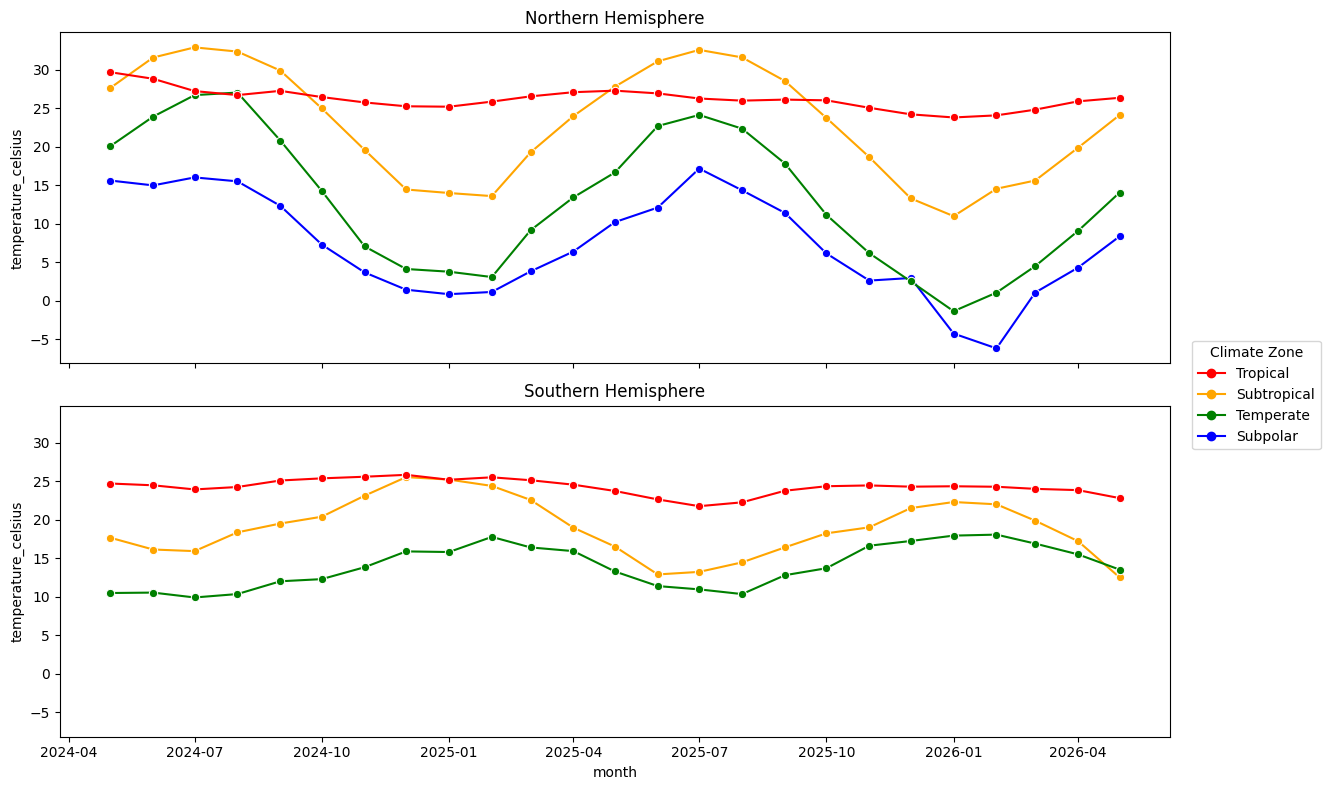

In [29]:
# monthly average temp by climate_zone

monthly_temp = (
    df.groupby([df['last_updated'].dt.to_period('M'), 'climate_zone', 'hemisphere'])['temperature_celsius']
    .mean()
    .reset_index()
)

monthly_temp['month'] = monthly_temp['last_updated'].dt.to_timestamp()

# plot

palette = {
    'Tropical': 'red',
    'Subtropical': 'orange',
    'Temperate': 'green',
    'Subpolar': 'blue'
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    sharey=True
)

sns.lineplot(
    data=monthly_temp[monthly_temp['hemisphere'] == 'Northern'],
    x='month',
    y='temperature_celsius',
    hue='climate_zone',
    palette=palette,
    marker='o',
    ax=axes[0],
    legend=False
)

sns.lineplot(
    data=monthly_temp[monthly_temp['hemisphere'] == 'Southern'],
    x='month',
    y='temperature_celsius',
    hue='climate_zone',
    palette=palette,
    marker='o',
    ax=axes[1],
    legend=False
)

axes[0].set_title('Northern Hemisphere')
axes[1].set_title('Southern Hemisphere')

# Shared legend outside plot
from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color='red', marker='o', label='Tropical'),
    Line2D([0], [0], color='orange', marker='o', label='Subtropical'),
    Line2D([0], [0], color='green', marker='o', label='Temperate'),
    Line2D([0], [0], color='blue', marker='o', label='Subpolar')
]

fig.legend(
    handles=legend_handles,
    title='Climate Zone',
    loc='center left',
    bbox_to_anchor=(0.85, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space for legend
plt.show()

- Average temperatures exhibit clear seasonal cycles across all climate zones, with the Northern and Southern Hemispheres showing opposite seasonal patterns.
- Tropical regions remain the most stable, maintaining temperatures around 24–28°C throughout the year regardless of hemisphere.
- Subpolar regions experience the greatest seasonal variation, with temperatures ranging from below 0°C in winter to above 15°C in summer in the Northern Hemisphere.
- Temperate and Subtropical regions show intermediate variability, with pronounced summer peaks and winter lows, though less extreme than Subpolar climates.
- The seasonal temperature curves become increasingly pronounced from Tropical → Subtropical → Temperate → Subpolar, indicating that temperature variability generally increases with distance from the equator.
- The mirrored patterns between hemispheres confirm that the observed temperature fluctuations are driven primarily by seasonal changes rather than long-term trends.
- There are no observations for Subpolar zone in the Southern hemishere. This is consistent with the fact that this region of earth is occupied by the Southern/Antarctic Ocean and there is almost no land here.

### Seasonal temperature patterns

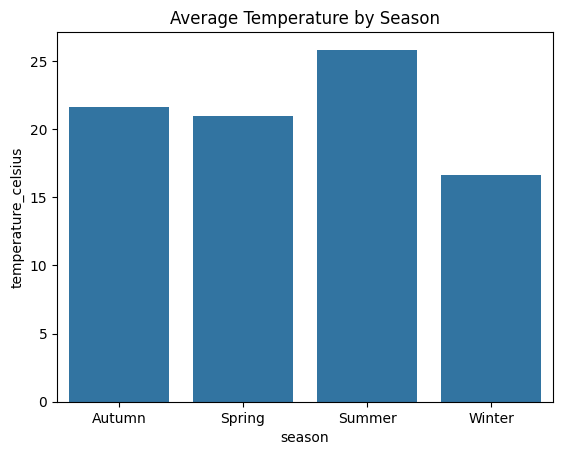

In [22]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['last_updated'].dt.month.apply(get_season)

season_avg = (
    df.groupby('season')['temperature_celsius']
    .mean()
    .reset_index()
)

sns.barplot(
    data=season_avg,
    x='season',
    y='temperature_celsius'
)

plt.title('Average Temperature by Season')
plt.show()


Average temperature varies by season, with Summer being the warmest season (≈26°C) and Winter the coldest (≈17°C). Spring and Autumn have similar average temperatures (≈21–22°C), representing transitional periods between summer and winter. Overall, the results show the expected seasonal temperature cycle, with temperatures increasing toward summer and decreasing toward winter.

### Precipitation seasonality

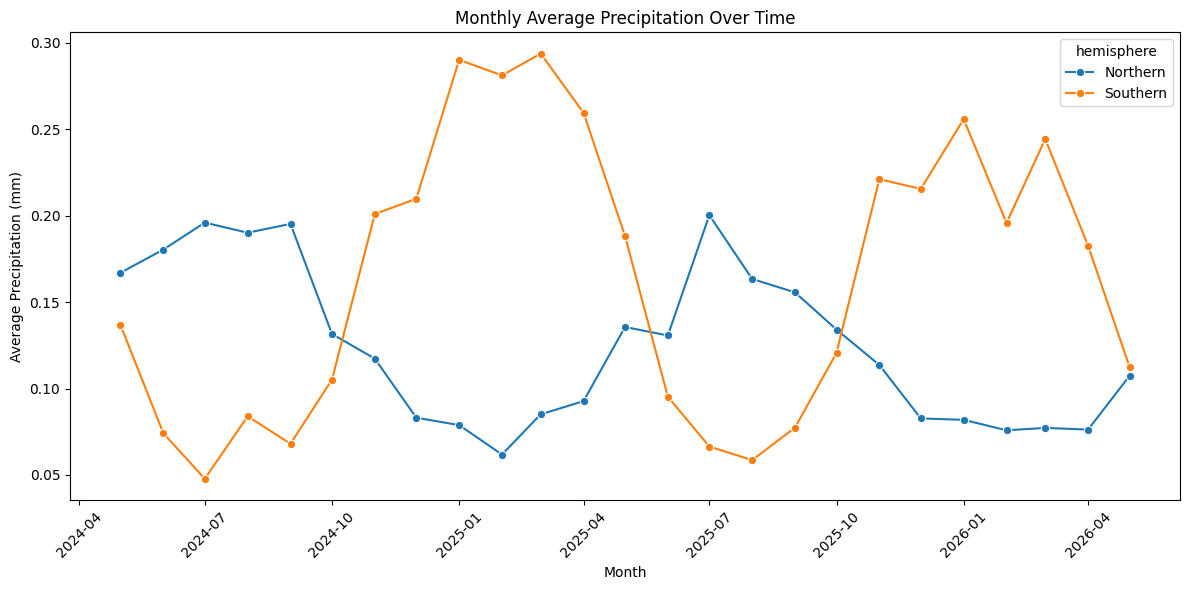

In [30]:
# Monthly average precipitation over time

monthly_precip = (
    df.groupby([df['last_updated'].dt.to_period('M'), 'hemisphere'])['precip_mm']
      .mean()
      .reset_index()
)

monthly_precip['month'] = monthly_precip['last_updated'].dt.to_timestamp()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_precip,
    x='month',
    y='precip_mm',
    hue='hemisphere',
    marker='o'
)

plt.title('Monthly Average Precipitation Over Time')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Average precipitation displays distinct seasonal patterns that differ between hemispheres similar to that of temperature.
- The Southern Hemisphere generally records higher and more variable precipitation levels, while the Northern Hemisphere exhibits lower and more stable precipitation. This is opposite to what was observed with temperature as in higher values and more variablity was in Northern hemishpere.
- The opposing seasonal cycles highlight the importance of analyzing hemispheres separately, as global averages can obscure meaningful regional rainfall patterns.

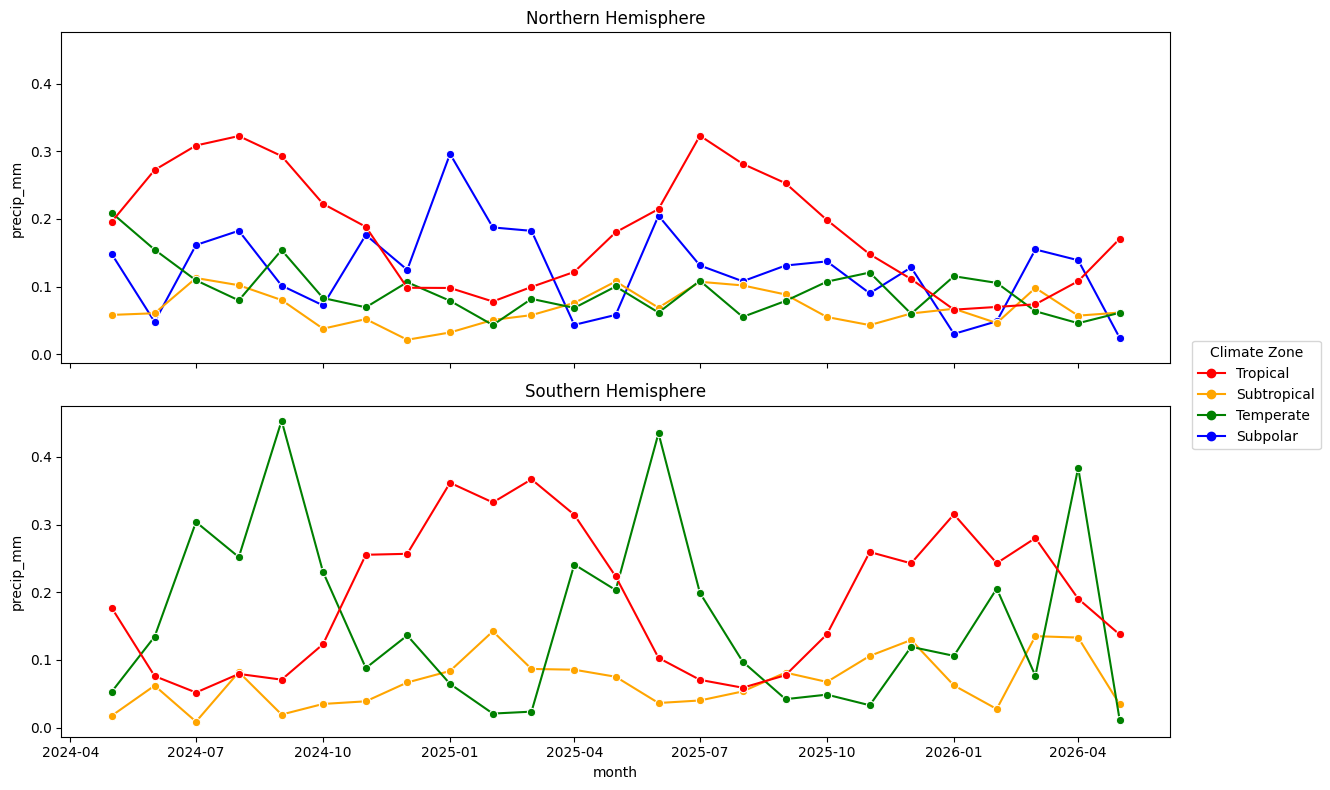

In [31]:
# monthly average precipitation by climate_zone

monthly_precip = (
    df.groupby([df['last_updated'].dt.to_period('M'), 'climate_zone', 'hemisphere'])['precip_mm']
    .mean()
    .reset_index()
)

monthly_precip['month'] = monthly_precip['last_updated'].dt.to_timestamp()

# plot

palette = {
    'Tropical': 'red',
    'Subtropical': 'orange',
    'Temperate': 'green',
    'Subpolar': 'blue'
}

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    sharey=True
)

sns.lineplot(
    data=monthly_precip[monthly_precip['hemisphere'] == 'Northern'],
    x='month',
    y='precip_mm',
    hue='climate_zone',
    palette=palette,
    marker='o',
    ax=axes[0],
    legend=False
)

sns.lineplot(
    data=monthly_precip[monthly_precip['hemisphere'] == 'Southern'],
    x='month',
    y='precip_mm',
    hue='climate_zone',
    palette=palette,
    marker='o',
    ax=axes[1],
    legend=False
)

axes[0].set_title('Northern Hemisphere')
axes[1].set_title('Southern Hemisphere')

# Shared legend outside plot
from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color='red', marker='o', label='Tropical'),
    Line2D([0], [0], color='orange', marker='o', label='Subtropical'),
    Line2D([0], [0], color='green', marker='o', label='Temperate'),
    Line2D([0], [0], color='blue', marker='o', label='Subpolar')
]

fig.legend(
    handles=legend_handles,
    title='Climate Zone',
    loc='center left',
    bbox_to_anchor=(0.85, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

- Precipitation patterns vary considerably across both climate zones and hemispheres, with no single consistent seasonal trend observed across all regions.
- Tropical regions generally receive the highest precipitation, although rainfall fluctuates throughout the year and differs between hemispheres.
- Temperate and Subpolar regions exhibit the greatest month-to-month variability, with several pronounced precipitation spikes.
- Subtropical regions tend to receive lower and more stable precipitation levels compared to the other climate zones.
- Unlike temperature, precipitation does not show a smooth seasonal cycle and appears to be influenced by more localized and region-specific weather patterns.
- Temperature showed clear, mirrored seasonal patterns between hemispheres, whereas precipitation exhibits much greater irregularity, suggesting rainfall is less strongly governed by latitude alone and more dependent on regional climate systems.

## Environmental Impact

### Air Quality Analysis

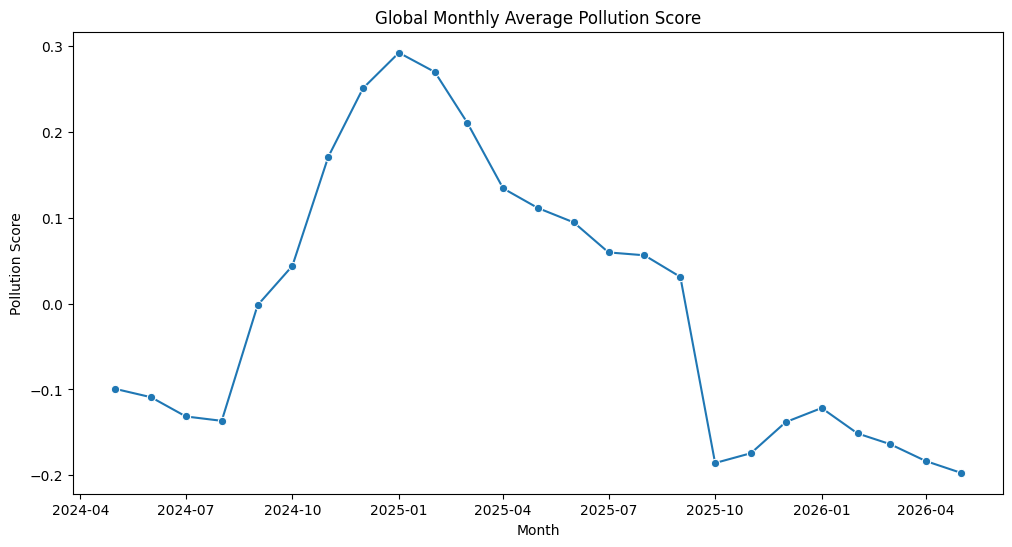

In [33]:
monthly_pollution = (
    df.groupby(df['last_updated'].dt.to_period('M'))['pollution_score']
      .mean()
      .reset_index()
)

monthly_pollution['month'] = monthly_pollution['last_updated'].dt.to_timestamp()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_pollution,
    x='month',
    y='pollution_score',
    marker='o'
)

plt.title('Global Monthly Average Pollution Score')
plt.xlabel('Month')
plt.ylabel('Pollution Score')
plt.show()

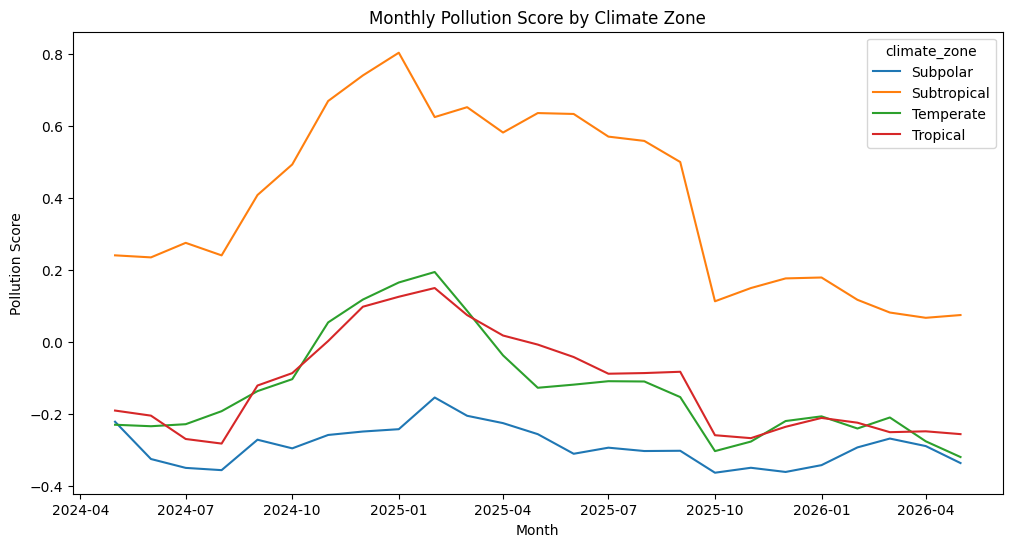

In [35]:
monthly_pollution = (
    df.groupby([
        df['last_updated'].dt.to_period('M'),
        'climate_zone'
    ])['pollution_score']
      .mean()
      .reset_index()
)

monthly_pollution['month'] = monthly_pollution['last_updated'].dt.to_timestamp()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_pollution,
    x='month',
    y='pollution_score',
    hue='climate_zone'
)

plt.title('Monthly Pollution Score by Climate Zone')
plt.xlabel('Month')
plt.ylabel('Pollution Score')
plt.show()

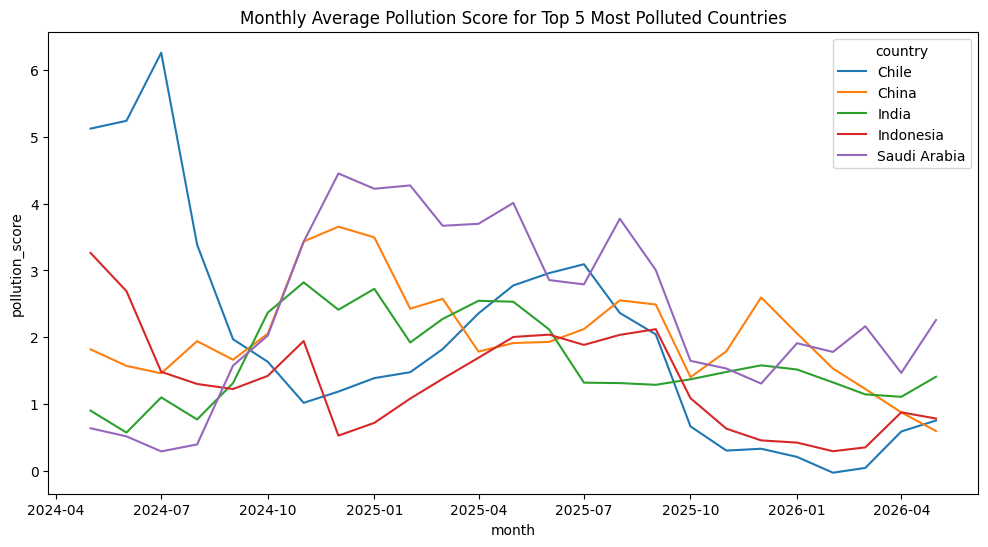

In [39]:
top_5_countries = (
    df_top.groupby('country')['pollution_score']
          .mean()
          .nlargest(5)
          .index
)

df_top_5 = df_top[df_top['country'].isin(top_5_countries)]

monthly_country = (
    df_top_5.groupby([
        df_top_5['last_updated'].dt.to_period('M'),
        'country'
    ])['pollution_score']
      .mean()
      .reset_index()
)

monthly_country['month'] = monthly_country['last_updated'].dt.to_timestamp()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_country,
    x='month',
    y='pollution_score',
    hue='country'
)

plt.title('Monthly Average Pollution Score for Top 5 Most Polluted Countries')
plt.show()

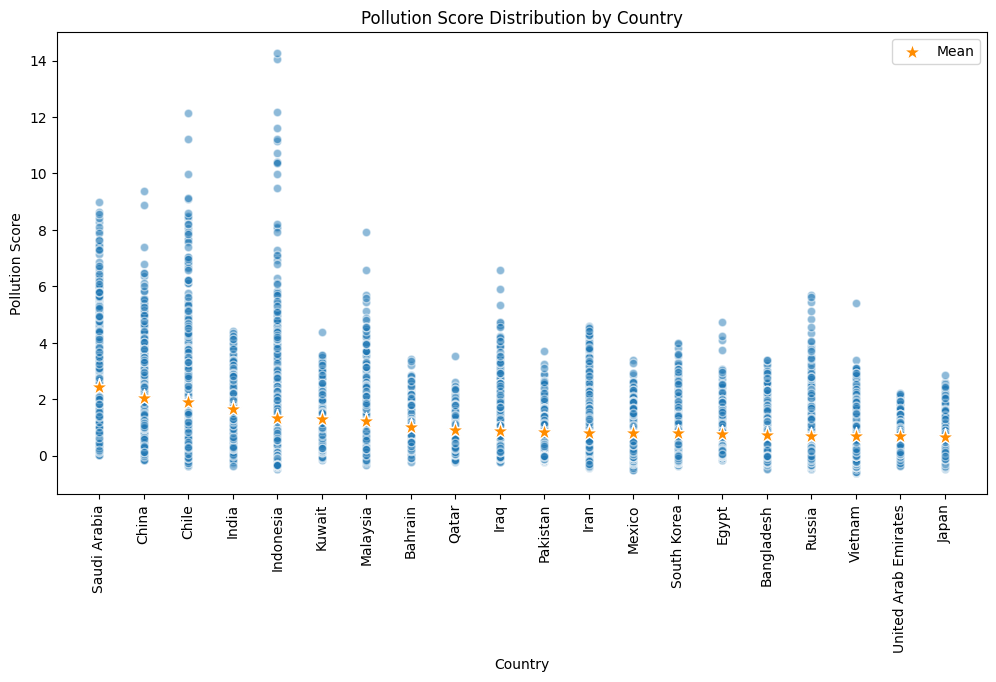

In [55]:
top_countries = (
    df_temp.groupby('country')['pollution_score']
           .mean()
           .nlargest(20)
           .index
)

df_top = df_temp[df_temp['country'].isin(top_countries)]

country_order = (
    df_top.groupby('country')['pollution_score']
          .mean()
          .sort_values(ascending=False)
          .index
)

df_top['country'] = pd.Categorical(
    df_top['country'],
    categories=country_order,
    ordered=True
)

country_means = (
    df_top.groupby('country', observed=False)['pollution_score']
          .mean()
          .reset_index()
)

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_top,
    x='country',
    y='pollution_score',
    alpha=0.5,
    s=150,
    marker='.',
)

sns.scatterplot(
    data=country_means,
    x='country',
    y='pollution_score',
    color='darkorange',
    s=170,
    label='Mean',
    marker='*'
)

plt.xticks(rotation=90)
plt.title('Pollution Score Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Pollution Score')
plt.legend()
plt.show()

- Saudi Arabia, China, Chile, India, and Indonesia have the highest average pollution scores, with Saudi Arabia showing the highest mean pollution level.
- Indonesia exhibits the greatest variability and highest pollution outliers, indicating occasional severe pollution episodes.
- Pollution distributions differ considerably across countries, suggesting that both pollution intensity and consistency vary by region.
- The top five most polluted countries all show clear month-to-month fluctuations, indicating that pollution levels are influenced by seasonal or temporal factors.
- Chile and Saudi Arabia experience the largest pollution peaks, while China and India show relatively more stable trends.
- Subtropical regions consistently record the highest pollution scores, whereas subpolar regions maintain the lowest levels throughout the study period.
- Most climate zones show a pollution peak around late 2024 to early 2025, followed by a gradual decline thereafter.
- The global average pollution score peaks in early 2025 and declines steadily afterward, suggesting an overall reduction in pollution intensity across the dataset over time.

### Air quality correlation with weather features

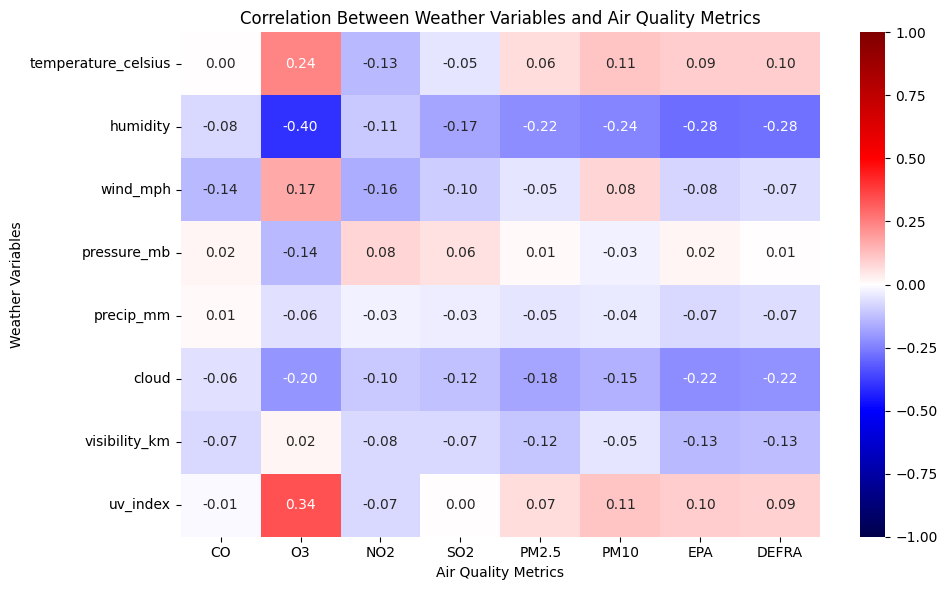

In [66]:
weather_cols = [
    'temperature_celsius',
    'humidity',
    'wind_mph',
    'pressure_mb',
    'precip_mm',
    'cloud',
    'visibility_km',
    'uv_index'
]

air_cols = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_us-epa-index',
    'air_quality_gb-defra-index'
]


corr_matrix = df[weather_cols + air_cols].corr()

weather_vs_air = corr_matrix.loc[weather_cols, air_cols]
weather_vs_air.columns = [
    'CO',
    'O3',
    'NO2',
    'SO2',
    'PM2.5',
    'PM10',
    'EPA',
    'DEFRA'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    weather_vs_air,
    annot=True,
    fmt='.2f',
    cmap='seismic',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Weather Variables and Air Quality Metrics')
plt.xlabel('Air Quality Metrics')
plt.ylabel('Weather Variables')
plt.tight_layout()

plt.show()

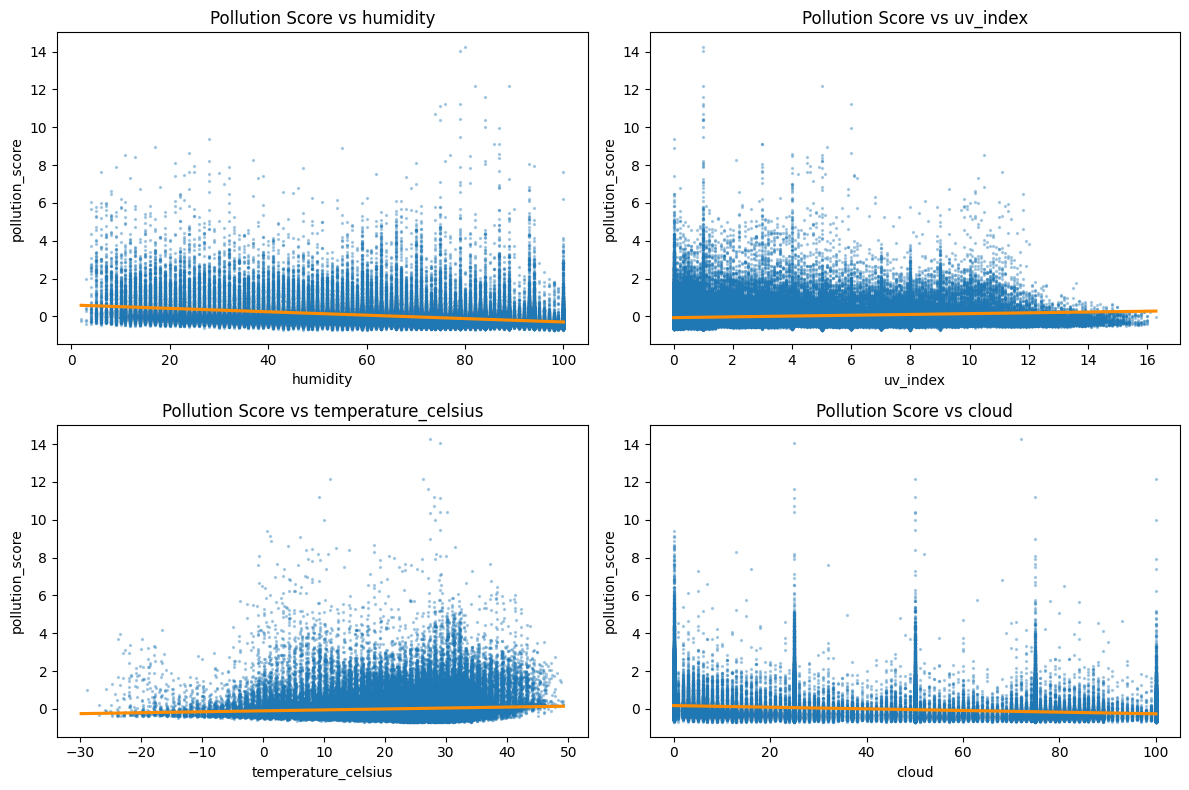

In [61]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

features = [
    'humidity',
    'uv_index',
    'temperature_celsius',
    'cloud',
    'visibility_km'
]

for ax, feature in zip(axes.flatten(), features):
    sns.regplot(
        data=df,
        x=feature,
        y='pollution_score',
        scatter_kws={'s':2, 'alpha':0.3},
        line_kws={'color':'darkorange'},
        ax=ax
    )
    ax.set_title(f'Pollution Score vs {feature}')

plt.tight_layout()
plt.show()

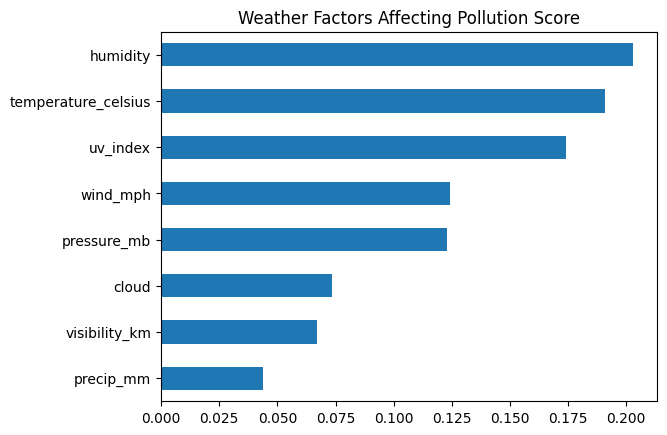

In [60]:
from sklearn.ensemble import RandomForestRegressor

X = df[weather_cols]
y = df['pollution_score']

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

importances.plot.barh()
plt.title('Weather Factors Affecting Pollution Score')
plt.show()

- Humidity, temperature, and UV index are the most important weather factors affecting pollution score.
- Humidity shows a slight negative relationship with pollution, suggesting higher humidity is generally associated with lower pollution levels.
- Temperature and UV index have a positive relationship with ozone, indicating that warmer and sunnier conditions favor ozone formation.
- Wind speed has a moderate influence on pollution, likely because stronger winds help disperse pollutants.
- Precipitation has the weakest impact on pollution among the weather variables analyzed.
- Ozone shows the strongest correlation with weather conditions, particularly UV index and humidity.
- Particulate pollutants (PM2.5 and PM10) tend to decrease slightly with higher humidity and cloud cover.
- Overall, weather affects air quality, but the relationships are generally weak, suggesting that multiple environmental factors contribute to pollution levels.